# EDA and model training — Heart Risk

Exploratory analysis, preprocessing (using `src`), model training (CatBoost), saving artifacts, and generating test predictions. Application code is in `src/` and imported here.

## 1. Load data and EDA

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent if (Path.cwd().parent / "heart_train.csv").exists() else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TRAIN_PATH = ROOT / "heart_train.csv"
TEST_PATH = ROOT / "heart_test.csv"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train columns:", list(train.columns))

Train shape: (8685, 28)
Test shape: (966, 27)
Train columns: ['Unnamed: 0', 'Age', 'Cholesterol', 'Heart rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Heart Attack Risk (Binary)', 'Blood sugar', 'CK-MB', 'Troponin', 'Gender', 'Systolic blood pressure', 'Diastolic blood pressure', 'id']


In [2]:
from src.config import TARGET_COL

print("Target distribution (train):")
print(train[TARGET_COL].value_counts(dropna=False))
print("\nMissing values per column:")
print(train.isna().sum()[train.isna().sum() > 0])

Target distribution (train):
Heart Attack Risk (Binary)
0.0    5672
1.0    3013
Name: count, dtype: int64

Missing values per column:
Diabetes                           243
Family History                     243
Smoking                            243
Obesity                            243
Alcohol Consumption                243
Previous Heart Problems            243
Medication Use                     243
Stress Level                       243
Physical Activity Days Per Week    243
dtype: int64


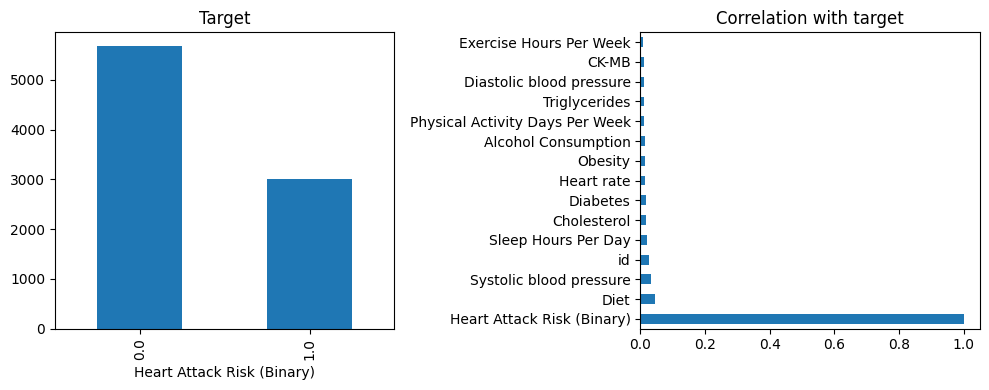

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train[TARGET_COL].value_counts().plot(kind="bar", ax=axes[0], title="Target")
train.select_dtypes(include=[np.number]).corrwith(train[TARGET_COL]).abs().sort_values(ascending=False).head(15).plot(kind="barh", ax=axes[1], title="Correlation with target")
plt.tight_layout()
plt.show()

## 2. Preprocessing and training

In [4]:
from src.preprocessing import HeartRiskPreprocessor
from src.config import ARTIFACTS_DIR, MODEL_PATH, PREPROCESSOR_PATH

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

preprocessor = HeartRiskPreprocessor()
X_train = preprocessor.fit_transform(train)
y_train = train[TARGET_COL].astype(int)
print("Feature matrix shape:", X_train.shape)
preprocessor.save(PREPROCESSOR_PATH)

Feature matrix shape: (8685, 25)


In [5]:
# F1-macro: учитывает оба класса при дисбалансе (65% Low / 35% High)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score
import catboost as cb

model = cb.CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False,
    auto_class_weights="Balanced",  # учёт дисбаланса
)
model.fit(X_train, y_train)

# Manual CV (CatBoost may not implement sklearn __sklearn_tags__)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    m = cb.CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, random_seed=42, verbose=False, auto_class_weights="Balanced")
    m.fit(X_tr, y_tr)
    scores.append(f1_score(y_val, m.predict(X_val), average="macro"))
scores = np.array(scores)
print("CV F1-macro:", scores.mean(), "±", scores.std())
print(classification_report(y_train, model.predict(X_train), target_names=["Low", "High"]))

CV F1-macro: 0.539414452190262 ± 0.007611301049153836
              precision    recall  f1-score   support

         Low       0.97      0.87      0.92      5672
        High       0.80      0.95      0.87      3013

    accuracy                           0.90      8685
   macro avg       0.88      0.91      0.89      8685
weighted avg       0.91      0.90      0.90      8685



In [6]:
from src.model import HeartRiskModel

wrapper = HeartRiskModel(estimator=model)
wrapper.save(MODEL_PATH)  # or ARTIFACTS_DIR / "model.cbm" for CatBoost
print("Model saved to", MODEL_PATH)

Model saved to /Users/luvgreyair/ya/heart-risk-ml-project/artifacts/model.joblib


## 3. Predictions on test set

In [7]:
from src.pipeline import HeartRiskPipeline

pipeline = HeartRiskPipeline().load()
predictions_df = pipeline.predict_from_csv(TEST_PATH)
out_path = ROOT / "predictions.csv"
predictions_df.to_csv(out_path, index=True)
print("Predictions saved to", out_path)
print(predictions_df.head(10))

Predictions saved to /Users/luvgreyair/ya/heart-risk-ml-project/predictions.csv
     id  prediction
0  7746           0
1  4202           0
2  6632           0
3  4639           0
4  4825           0
5  1076           1
6  5020           0
7  4267           0
8  4003           1
9  2519           1


## Выводы

- **Данные:** 8685 train, 966 test; таргет бинарный (Low/High risk), дисбаланс ~65% / 35%; пропуски в 9 колонках — заполнены медианой.
- **Препроцессинг:** идентификаторы и таргет исключены; категории (Gender, Diet) закодированы; порядок фичей фиксирован в `HeartRiskPreprocessor`.
- **Метрика:** F1-macro — учитывает оба класса при дисбалансе (в ТЗ метрику выбираем самостоятельно).
- **Модель:** CatBoost с `auto_class_weights="Balanced"` для учёта дисбаланса. После переобучения перезапусти ячейки обучения и сохранения, затем заново сгенерируй `predictions.csv`.